# 一、前言

完成 多输入多输出通道，汇聚层和卷积神经网络（LeNet）相应的代码示例并分析，为下一节纯手写 CNN on CIFAR-10 做准备

# 二、代码

## 准备

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

print(hasattr(d2l, 'train_ch6'))   # 必须输出 True
print(torch.cuda.is_available())   # True 有 GPU，False 用 CPU（LeNet 也跑得动）

True
True


## 1.多输入通道：每个通道一个核，结果相加

In [2]:
def corr2d_multi_in(X, K):
    # 遍历 X 和 K 的第0维（通道维），每个通道做互相关，再全部相加
    return sum(d2l.corr2d(x, k) for x, k in zip(X, K))

# 为什么逐通道算完相加——多输入通道的含义就是"每个通道用自己的核提取特征，最后把各通道响应叠加"。zip 同时遍历 X 和 K 的通道

# ......验证.......

X = torch.tensor([[[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]],
                  [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]]])
K = torch.tensor([[[0.0, 1.0], [2.0, 3.0]], [[1.0, 2.0], [3.0, 4.0]]])
corr2d_multi_in(X, K)    # 期望 tensor([[ 56.,  72.], [104., 120.]])

tensor([[ 56.,  72.],
        [104., 120.]])

## 2.多输出通道：一组核 = 一个输出通道

In [3]:
def corr2d_multi_in_out(X, K):
    # K 的第0维是输出通道：每个输出通道对应一组核，逐组算完再堆叠
    return torch.stack([corr2d_multi_in(X, k) for k in K], 0)
# 核的形状从 (c_i, k_h, k_w) 变成 (c_o, c_i, k_h, k_w)——先输出通道，再输入通道，再空间尺寸，这个顺序以后天天见，背下来。


# ......验证.......

K = torch.stack((K, K + 1, K + 2), 0)
K.shape    # torch.Size([3, 2, 2, 2])
corr2d_multi_in_out(X, K)

tensor([[[ 56.,  72.],
         [104., 120.]],

        [[ 76., 100.],
         [148., 172.]],

        [[ 96., 128.],
         [192., 224.]]])

torch.stack([corr2d_multi_in(X, k) for k in K], 0)<br>
`for k in K`<br>
K.shape = [3, 2, 2, 2]<br>
沿着第 0 维（输出通道维度）循环：<br>
- 第 1 轮：`k = K[0]` → shape `(2,2,2)`<br>
这是生成**第 0 号输出特征图**所需要的一整套卷积核（包含 2 个输入通道各自的 2×2 核）<br>
- 第 2 轮：`k = K[1]` → shape `(2,2,2)`，生成第 1 张输出图<br>
- 第 3 轮：`k = K[2]` → shape `(2,2,2)`，生成第 2 张输出图<br>
 每一个 `k`，就是**单输出通道对应的完整核组 `(Ci, kh, kw)`**

 `corr2d_multi_in(X, k)`<br>
调用之前写好的**多输入通道、单输出通道函数**。<br>
作用：输入多张通道图 + 一整套核，运算后**输出 1 张二维特征图**。<br>
本例返回结果：`shape=(2,2)`<br>
于是列表推导跑完后，得到列表：<br>
[ feat_map0 , feat_map1 , feat_map2 ],3 个独立张量，每个都是 (2,2)

torch.stack((K, K+1, K+2),0)<br>
`stack`：**新增一个维度**，把多张特征图沿着维度 0 摞起来。<br>
堆叠前列表：3 × (2,2)<br>
堆叠后输出张量形状：`(3, 2, 2)`(输出通道数，特征图高，特征图宽)<br>
`K`：原始卷积核<br>
`K+1`：核里面**每一个权重数值全部 + 1**<br>
`K+2`：核里面每一个权重数值全部 + 2<br>
沿着维度 0，把三份核组堆叠，新增输出通道维度。<br>
变换前后维度：<br>
`(2,2,2)` → **(3, 2, 2, 2)**<br>
`(Co, Ci, kh, kw)` = (输出通道，输入通道，核高，核宽)

## 3.1×1 卷积（重点，ResNet 地基）

In [4]:
def corr2d_multi_in_out_1x1(X, K):
    c_i, h, w = X.shape    # 取出输入通道、高、宽
    c_o = K.shape[0]       # 取出输出通道数

    X = X.reshape((c_i, h * w))
    '''
    空间维度展平：把 h×w 的二维像素网格，拉成一列列像素
    X 形状：(c_i, h*w)
    每【一列】代表图像上【同一个空间像素位置】，它有 c_i 个通道的值
    '''
    
    K = K.reshape((c_o, c_i))
    '''
    1×1的空间尺寸直接抹掉
    K原来 (c_o, c_i, 1, 1) → reshape后变成 (c_o, c_i)
    这就是一个标准的全连接权重矩阵！
    '''

    # 全连接层中的矩阵乘法
    Y = torch.matmul(K, X)
    '''
    矩阵乘法 (c_o × c_i) @ (c_i × h*w) = (c_o × h*w)
    每一列独立运算！不同像素之间互不干扰。
    '''
    
    # 把展平的像素，恢复回空间形状 (c_o, h, w)
    return Y.reshape((c_o, h, w))

#....... 1×1 与普通卷积的等价性验证.........

X = torch.normal(0, 1, (3, 3, 3))      # (Ci=3, H=3, W=3)
K = torch.normal(0, 1, (2, 3, 1, 1))   # (Co=2, Ci=3, kh=1, kw=1)
Y1 = corr2d_multi_in_out_1x1(X, K)     # 矩阵乘法版本（通道全连接）
Y2 = corr2d_multi_in_out(X, K)         # 普通多输入多输出卷积版本
assert float(torch.abs(Y1 - Y2).sum()) < 1e-6
# 断言不报错 = 两个实现数值等价，证明"1×1 卷积 = 通道维全连接"不是比喻，是数学等价
# 1×1 卷积，没有在空间（高、宽）方向做特征提取；它只对通道维度做变换，等价于对每一个像素点，独立跑一遍全连接层

输入：通道数 $C_i=3$，高 H=3，宽 W=3<br>
输出：通道数 $C_o=2$，高 H=3，宽 W=3

1.原始张量形状<br>
输入 $X:\quad \boldsymbol{(3,\;3,\;3)}$<br>
$ X=
\left[
\underbrace{
\begin{bmatrix}
x_{000} & x_{001} & x_{002}\\
x_{010} & x_{011} & x_{012}\\
x_{020} & x_{021} & x_{022}
\end{bmatrix}}_{\text{通道0}},\;
\underbrace{
\begin{bmatrix}
x_{100} & x_{101} & x_{102}\\
x_{110} & x_{111} & x_{112}\\
x_{120} & x_{121} & x_{122}
\end{bmatrix}}_{\text{通道1}},\;
\underbrace{
\begin{bmatrix}
x_{200} & x_{201} & x_{202}\\
x_{210} & x_{211} & x_{212}\\
x_{220} & x_{221} & x_{222}
\end{bmatrix}}_{\text{通道2}}
\right] $ 

卷积核$K:\quad \boldsymbol{(2,\;3,\;1,\;1)}$<br>
Co=2套核；每套核包含Ci=3个1×1权重<br>
$K=
\left[
\underbrace{
\begin{bmatrix}k_{00}\end{bmatrix},\;
\begin{bmatrix}k_{01}\end{bmatrix},\;
\begin{bmatrix}k_{02}\end{bmatrix}}_{\text{输出通道0的3个1×1核}},\quad
\underbrace{
\begin{bmatrix}k_{10}\end{bmatrix},\;
\begin{bmatrix}k_{11}\end{bmatrix},\;
\begin{bmatrix}k_{12}\end{bmatrix}}_{\text{输出通道1的3个1×1核}}
\right]$



2.X.reshape((c_i, h * w))<br>
$h\times w = 3\times3 = \boldsymbol{9}$
新形状：(3, 9)<br>
$X_{\text{reshaped}}=
\overset{\text{像素位置}}{
\begin{array}{ccccccccc}
(0,0)&(0,1)&(0,2)&(1,0)&(1,1)&(1,2)&(2,0)&(2,1)&(2,2)\\
\downarrow&\downarrow&\downarrow&\downarrow&\downarrow&\downarrow&\downarrow&\downarrow&\downarrow\\
x_{000}&x_{001}&x_{002}&x_{010}&x_{011}&x_{012}&x_{020}&x_{021}&x_{022}\\
x_{100}&x_{101}&x_{102}&x_{110}&x_{111}&x_{112}&x_{120}&x_{121}&x_{122}\\
x_{200}&x_{201}&x_{202}&x_{210}&x_{211}&x_{212}&x_{220}&x_{221}&x_{222}
\end{array}
}
\begin{matrix}\leftarrow\text{输入通道0}\\ \leftarrow\text{输入通道1}\\ \leftarrow\text{输入通道2}\end{matrix}$

**每一列 = 原图上一个空间像素点，3 个通道的值**<br>
 一共 9 列，对应原图 9 个像素。


3.K.reshape((c_o, c_i))<br>
原始形状 (2,3,1,1) → 扔掉后面两个 1，变成 (2, 3)<br>
$K_{\text{reshaped}}=
\begin{bmatrix}
k_{00} & k_{01} & k_{02}\\
k_{10} & k_{11} & k_{12}
\end{bmatrix}$,这就是一个普通全连接权重矩阵。<br>



4.Y = torch.matmul(K, X)<br>
矩阵乘法：$(2\times 3)\;@\;(3\times 9) = \boldsymbol{(2\times9)}$

$Y=
\begin{bmatrix}
k_{00} & k_{01} & k_{02}\\
k_{10} & k_{11} & k_{12}
\end{bmatrix}
\cdot
\begin{bmatrix}
x_{000}&x_{001}&\dots&x_{022}\\
x_{100}&x_{101}&\dots&x_{122}\\
x_{200}&x_{201}&\dots&x_{222}
\end{bmatrix}$

拿第一列（像素 (0,0)）举例计算<br>
$\begin{align*}
y_{0,0}&=k_{00}\cdot x_{000}+k_{01}\cdot x_{100}+k_{02}\cdot x_{200}\\
y_{1,0}&=k_{10}\cdot x_{000}+k_{11}\cdot x_{100}+k_{12}\cdot x_{200}
\end{align*}$
**9 列像素，每一列都是独立、互不干扰地做一次通道方向加权求和！**
运算完得到：<br>
$Y=\begin{bmatrix}
y_{00}&y_{01}&y_{02}&y_{03}&y_{04}&y_{05}&y_{06}&y_{07}&y_{08}\\
y_{10}&y_{11}&y_{12}&y_{13}&y_{14}&y_{15}&y_{16}&y_{17}&y_{18}
\end{bmatrix}$


5.Y.reshape((c_o, h, w))<br>
把 9 个像素，重新摊回 3x3 的空间网格<br>
输出形状 (2, 3, 3)<br>
通道 0 输出：<br>
$Y_0=\begin{bmatrix}
y_{00}&y_{01}&y_{02}\\
y_{03}&y_{04}&y_{05}\\
y_{06}&y_{07}&y_{08}
\end{bmatrix}$

通道 1 输出：<br>
$ Y_1=\begin{bmatrix}
y_{10}&y_{11}&y_{12}\\
y_{13}&y_{14}&y_{15}\\
y_{16}&y_{17}&y_{18}
\end{bmatrix} $

## 4. 汇聚层- 手写 pool2d（和 corr2d 一模一样的骨架）

In [5]:
def pool2d(X, pool_size, mode = 'max'):
    p_h, p_w = pool_size     # 取出池化窗口高、宽
    Y = torch.zeros(X.shape[0] - p_h + 1, X.shape[1] - p_w + 1)
    # 输出尺寸公式： n_out = n_in - pool_size + 1  (padding=0, stride=1)
    
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            # 截取窗口区域 X[i:i+p_h , j:j+p_w]
            if mode == 'max':
                Y[i, j] = X[i: i + p_h, j: j + p_w].max()    # 最大池化,选取区域里最大的元素作为输出值
            elif mode == 'avg':
                Y[i, j] = X[i: i + p_h, j: j + p_w].mean()   # 平均池化,选取区域里所有元素之和的平均值作为输出值
    return Y
# 和 corr2d 骨架一模一样，但没有核、没有乘法、没有可学习参数——只取窗口内 max 或 mean。这就是"池化是确定性的"

#............. 验证 max / avg.............

X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
pool2d(X, (2, 2))           # 期望 tensor([[4., 5.], [7., 8.]])
pool2d(X, (2, 2), 'avg')    # 期望 tensor([[2., 3.], [5., 6.]])

# nn.MaxPool2d 例子 1：默认 stride 的坑
X = torch.arange(16, dtype = torch.float32).reshape((1, 1, 4, 4))
pool2d = nn.MaxPool2d(3)
print(pool2d(X))    # 期望 tensor([[[[10.]]]])
'''
关键坑：MaxPool2d 默认 stride=kernel_size（这里 stride=3，4×4 直接压成 1×1）;
而 Conv2d 默认 stride=1。两个默认值不同——写 CIFAR 时搞混这个，尺寸全错。
'''

# MaxPool2d 例子 2、3：手动设定 padding/stride
pool2d = nn.MaxPool2d(3, padding = 1, stride = 2)
print(pool2d(X))   # 期望 tensor([[[[ 5.,  7.], [13., 15.]]]])
pool2d = nn.MaxPool2d((2, 3), stride = (2, 3), padding = (0, 1))
print(pool2d(X))   # 期望 tensor([[[[ 5.,  7.], [13., 15.]]]])
# 池化的尺寸公式和卷积完全一样

tensor([[[[10.]]]])
tensor([[[[ 5.,  7.],
          [13., 15.]]]])
tensor([[[[ 5.,  7.],
          [13., 15.]]]])


对比前面的 `corr2d`（互相关 / 卷积）：<br>
- 卷积：**有卷积核、做点积运算、权重可学习**<br>
- 池化：**没有核、没有乘法运算、没有可学习参数**；仅仅在滑动窗口内取最大值或平均值，运算结果完全由输入决定 → **确定性运算**<br>
池化作用：降采样（缩小特征图尺寸）、降低特征对位置的敏感度、减少计算量。

padding=1，在原图外围补一圈 0<br>
$\begin{bmatrix}
0 & 0 & 0 & 0 & 0 & 0\\
0 & \boldsymbol0 & \boldsymbol1 & \boldsymbol2 & \boldsymbol3 & 0\\
0 & \boldsymbol4 & \boldsymbol5 & \boldsymbol6 & \boldsymbol7 & 0\\
0 & \boldsymbol8 & \boldsymbol9 & \boldsymbol{10} & \boldsymbol{11} & 0\\
0 & \boldsymbol{12} & \boldsymbol{13} & \boldsymbol{14} & \boldsymbol{15} & 0\\
0 & 0 & 0 & 0 & 0 & 0
\end{bmatrix}$

padding = (0, 1),只在左右两边(宽度)补 1 列 0，上下不加填充<br>
$ \begin{bmatrix}
0 & 0 & 1 & 2 & 3 & 0\\
0 & 4 & 5 & 6 & 7 & 0\\
0 & 8 & 9 & 10 & 11 & 0\\
0 & 12 & 13 & 14 & 15 & 0
\end{bmatrix} $

## 5. 汇聚层-多通道：池化逐通道独立

In [6]:
X = torch.cat((X, X + 1), 1)    # 通道维 dim=1 连结 → 2 通道
pool2d = nn.MaxPool2d(3, padding = 1, stride = 2)
pool2d(X).shape     # 期望 torch.Size([1, 2, 2, 2])
# 池化不跨通道（输出通道数 = 输入通道数），和卷积"跨通道求和"不同——这是两者最重要的行为差异。
# MaxPool2d 永远每个通道单独运算，通道数目不会发生任何改变（卷积层才可以升降通道）

torch.Size([1, 2, 2, 2])

torch.cat(tensors, dim)<br>
全称：concatenate 拼接、串联<br>
作用：把多个张量，沿着你指定的某一个维度，拼在一起；其余所有维度的尺寸必须完全相等。<br>
`cat` **不会新建一个维度**，只会在已经存在的维度上延长。<br>
张量形状：`(N, C, H, W)`<br>
- dim 0 → N：batch 批次<br>
- dim 1 → C：channel 通道<br>
- dim 2 → H：height 高度（行）<br>
- dim 3 → W：width 宽度（列）<br>

## 6. LeNet- 网络结构

In [7]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size = 5, padding = 2),   
    nn.Sigmoid(),    # 第 2 层：激活函数，不改变张量形状
    nn.AvgPool2d(kernel_size = 2, stride = 2),  # 第 3 层：平均池化
    nn.Conv2d(6, 16, kernel_size = 5),
    nn.Sigmoid(),
    nn.AvgPool2d(kernel_size = 2, stride = 2),
    nn.Flatten(),     # 第 7 层：把除了批次 `dim=0` 以外的所有维度 (C,H,W) 全部摊平成一维向量
    nn.Linear(16 * 5 * 5, 120),   # 第 8 层：全连接层，400 → 120
    nn.Sigmoid(),
    nn.Linear(120, 84),
    nn.Sigmoid(),
    nn.Linear(84, 10))

# 构造测试输入：1张图片，单通道，28×28
X = torch.rand(size = (1, 1, 28, 28), dtype = torch.float32)
for layer in net:
    X = layer(X)        # 把张量 X 送入当前层做一次**前向传播计算**，用新的输出覆盖旧的 X
    print(layer.__class__.__name__, 'output shape: \t', X.shape)   # `layer.__class__.__name__`：获取当前层的类名（如`Conv2d`、`Linear`）

Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
Sigmoid output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
Sigmoid output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
Sigmoid output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
Sigmoid output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


为什么第一层 padding=2、第二层不 padding：第一层 k=5 要保 28×28（p=(5−1)/2=2）；第二层故意不补，让 14 缩到 10。"前几层保尺寸，后面随它缩"是 CNN 的通用节奏。

为什么 Sigmoid + AvgPool：ReLU 和 MaxPool 是 2012 年之后才流行的，LeNet 是 90 年代的模型——它是"历史的产物"，也是理解"现代为什么用 ReLU+MaxPool"的对照物。

为什么 Flatten 在中间：卷积输出是 4D (批量, 通道, 高, 宽)，全连接只要 2D。16*5*5=400 就是第二层池化后的展平长度。

## 7.训练

loss 0.459, train acc 0.829, test acc 0.821
40593.2 examples/sec on cuda:0


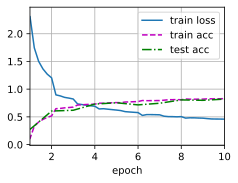

In [8]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size = batch_size)  # 加载 Fashion‑MNIST 数据集，返回两个迭代器
lr, num_epochs = 0.9, 10
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

为什么 lr=0.9 这么大：train_ch6 内部是 SGD + Xavier 初始化，这个组合下 0.9 是最优附近。若改成 0.01 会发现 loss 几乎不动——这是 d2l 调好的，别动。

45731.5 examples/sec on cuda:0<br>
- `45731.5 examples/sec`：每秒可以处理 45731 张图片<br>
- `cuda:0`：训练运行在第一张 GPU 显卡上，GPU 加速生效。

#  三、小结

卷积神经网络（CNN）是一类使用卷积层的网络。<br>

在 CNN 中，我们组合使用卷积层、非线性激活函数和汇聚层。<br>

为了构造高性能的 CNN，我们通常对卷积层进行排列，逐渐降低其表示的空间分辨率，同时增加通道数。（这句话就是明天 CIFAR 网络的设计纲领）<br>

在传统的 CNN 中，卷积块编码得到的表征在输出之前需由一个或多个全连接层进行处理。<br>
LeNet 是最早发布的 CNN 之一。

将平均汇聚层替换为最大汇聚层，会发生什么？<br>
MaxPool 取窗口内最大值、丢弃其他；AvgPool 把窗口内所有值平均，保留整体强度,这是两者最核心的差别;<br>
MaxPool 让特征更稀疏、突出；AvgPool 更平滑、平均;
现代 CNN 清一色用 MaxPool，不是因为它"抗过拟合"，而是因为它特征选择强、计算简单、配合 ReLU 效果好